<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


This exercise focuses on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


This exercise will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 182.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 176.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 145.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 155.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into browser:


In [5]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [6]:
dupp_rows = df.duplicated().sum()
print(dupp_rows)
df = df.drop_duplicates()
print("After remove:", df.duplicated().any())

10After remove: False

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [8]:
print(df["CodingActivities"].isnull().sum())
#print(df["CodingActivities"].isnull())

10971

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [11]:
df["CodingActivities"] = df["CodingActivities"].ffill()
df["CodingActivities"] 
#print(df["CodingActivities"].isnull().sum())


0                                                    Hobby
1        Hobby;Contribute to open-source projects;Other...
2        Hobby;Contribute to open-source projects;Other...
3        Hobby;Contribute to open-source projects;Other...
4        Hobby;Contribute to open-source projects;Other...
                               ...                        
65432                        Hobby;School or academic work
65433             Hobby;Contribute to open-source projects
65434                                                Hobby
65435    Hobby;Contribute to open-source projects;Profe...
65436    Hobby;Contribute to open-source projects;Profe...
Name: CodingActivities, Length: 65437, dtype: str

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, will identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [12]:
print (df["ConvertedCompYearly"].isnull().sum())
df["ConvertedCompYearly"] = df["ConvertedCompYearly"].isnull().fillna(df["ConvertedCompYearly"].mode()[0])
print (df["ConvertedCompYearly"].isnull().any())

df.columns

42002
False

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [17]:
!pip install scikit-learn
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['ConvertedCompYearly_Normalized'] = scaler.fit_transform(
    df[['ConvertedCompYearly']]
)

print(df['ConvertedCompYearly_Normalized'])

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
65432    1.0
65433    1.0
65434    1.0
65435    1.0
65436    1.0
Name: ConvertedCompYearly_Normalized, Length: 65437, dtype: float64

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [19]:
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
df["ConvertedCompYearly_Zscore"] = scaler1.fit_transform(df[["ConvertedCompYearly"]])

print (df["ConvertedCompYearly_Zscore"])
#OR
"""
df['ConvertedCompYearly_Zscore'] = (
    df['ConvertedCompYearly'] - df['ConvertedCompYearly'].mean()
) / df['ConvertedCompYearly'].std()
"""

0        0.74696
1        0.74696
2        0.74696
3        0.74696
4        0.74696
          ...   
65432    0.74696
65433    0.74696
65434    0.74696
65435    0.74696
65436    0.74696
Name: ConvertedCompYearly_Zscore, Length: 65437, dtype: float64

"\ndf['ConvertedCompYearly_Zscore'] = (\n    df['ConvertedCompYearly'] - df['ConvertedCompYearly'].mean()\n) / df['ConvertedCompYearly'].std()\n"

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


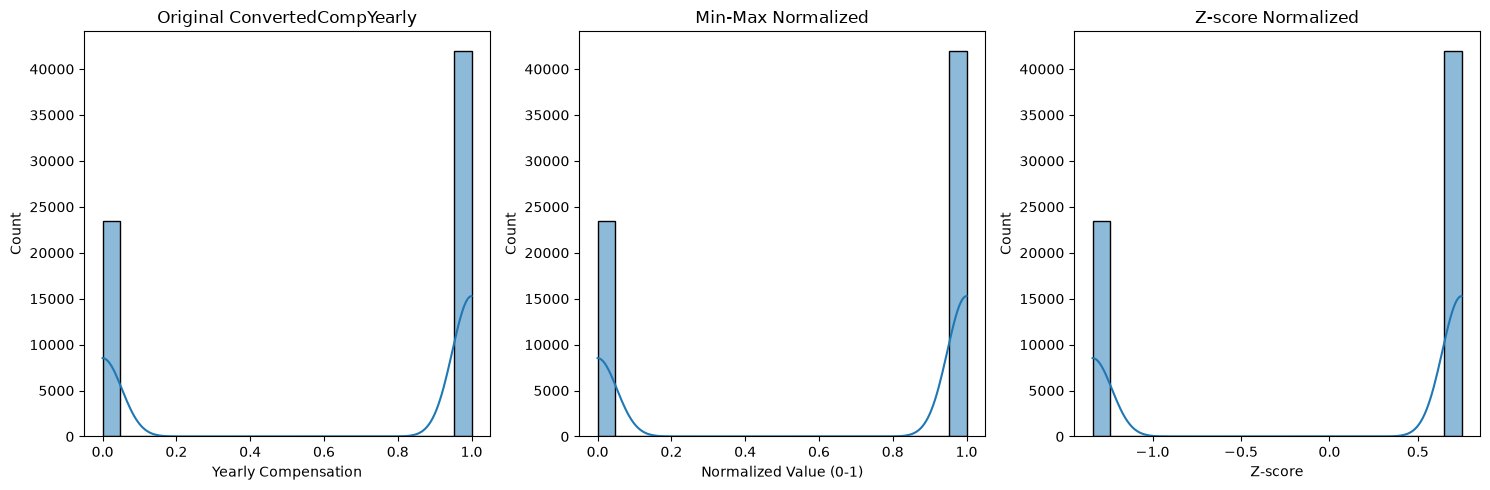

In [34]:
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(15, 5))

# Original salary distribution
plt.subplot(1, 3, 1)
sns.histplot(df['ConvertedCompYearly'], kde=True)
plt.title('Original ConvertedCompYearly')
plt.xlabel('Yearly Compensation')

# Min-Max normalized distribution
plt.subplot(1, 3, 2)
sns.histplot(df['ConvertedCompYearly_Normalized'], kde=True)
plt.title('Min-Max Normalized')
plt.xlabel('Normalized Value (0-1)')

# Z-score distribution
plt.subplot(1, 3, 3)
sns.histplot(df['ConvertedCompYearly_Zscore'], kde=True)
plt.title('Z-score Normalized')
plt.xlabel('Z-score')

plt.tight_layout()
plt.show()

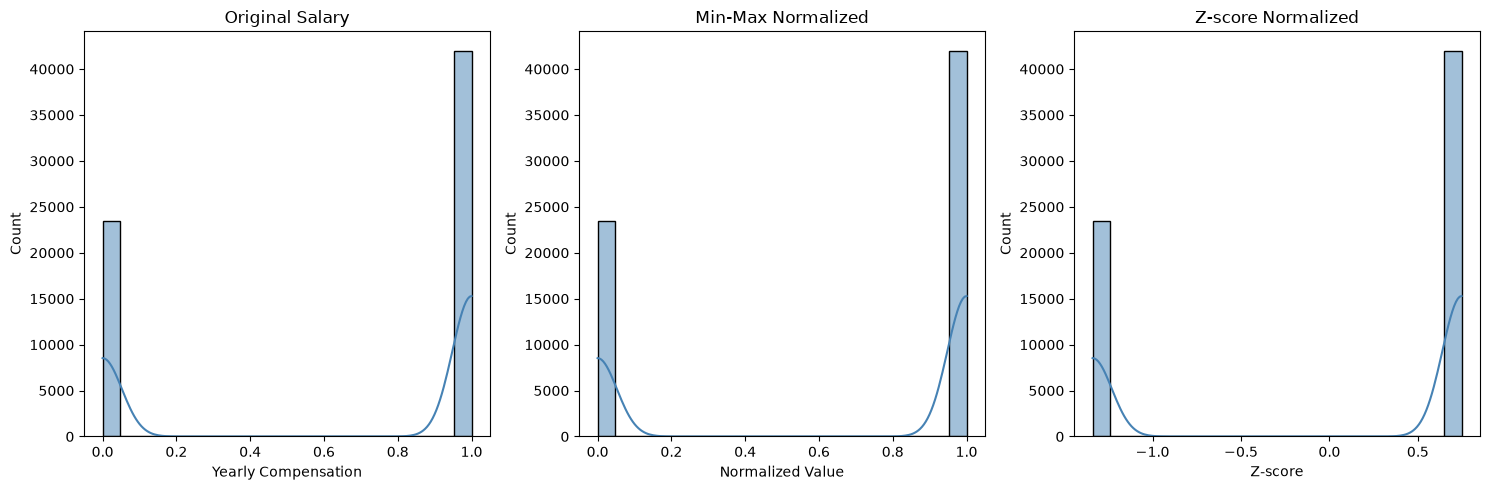

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    'ConvertedCompYearly',
    'ConvertedCompYearly_Normalized',
    'ConvertedCompYearly_Zscore'
]

titles = [
    'Original Salary',
    'Min-Max Normalized',
    'Z-score Normalized'
]

xlabels = [
    'Yearly Compensation',
    'Normalized Value',
    'Z-score'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title, xlabel in zip(axes, columns, titles, xlabels):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel(xlabel)

plt.tight_layout()
plt.show()




### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
